In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
import torchvision
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
from PIL import Image

from myDataset import *
from ArchitectureMethods import *
from MetricMethods import *

seed = 42
torch.manual_seed(seed)
torch.cuda.manual_seed(seed)
torch.cuda.manual_seed_all(seed)
torch.cpu.manual_seed = seed
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [2]:
# Sets current directory as ws
print(os.getcwd())
os.chdir('..')
print(os.getcwd())
# Checks if device is available (GPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

/user/HS401/ob00564/Documents/COM3001/All/Transfer Learning
/user/HS401/ob00564/Documents/COM3001/All
cuda


In [3]:

train_dataset = myDataset(directory = "DATASET/train", transform = train_transform)
val_dataset = myDataset(directory = "DATASET/validation", transform = val_transform)
test_dataset = myDataset(directory = "DATASET/test", transform = test_transform)

print(f'Train set length: '+ str(len(train_dataset)))
print(f'Test set length: '+ str(len(val_dataset)))
print(f'Validation set length: '+ str(len(test_dataset)))

train_loader = DataLoader(train_dataset, batch_size = 16, shuffle = True, num_workers=8 )
val_loader = DataLoader(val_dataset, batch_size = 16, shuffle = False, num_workers=8)
test_loader = DataLoader(test_dataset, batch_size = 16, shuffle = False, num_workers=8)


Train set length: 3241
Test set length: 404
Validation set length: 408


In [4]:
sorted_emotion_counts = train_dataset.getNoImagesInClass()
print(sorted_emotion_counts)
sorted_emotion_counts = val_dataset.getNoImagesInClass()
print(sorted_emotion_counts)
sorted_emotion_counts = test_dataset.getNoImagesInClass()
print(sorted_emotion_counts)

{'0': 396, '1': 406, '2': 382, '3': 416, '4': 382, '5': 425, '6': 834}
{'0': 49, '1': 51, '2': 47, '3': 52, '4': 48, '5': 53, '6': 104}
{'0': 50, '1': 51, '2': 48, '3': 52, '4': 48, '5': 54, '6': 105}


In [5]:
import torchvision.models as models
emotionTotal = 7
myModel_a = models.mobilenet_v2(weights = 'DEFAULT')
myModel_a.classifier = torch.nn.Linear(in_features=1280, out_features= 7)
print(myModel_a)

# Freeze all layers
for param in myModel_a.parameters():
    param.requires_grad = False

for param in myModel_a.classifier.parameters():
    param.requires_grad = True

# Unfreeze 16th, 17th, 18th layers
for id in range(16,19):
    for param in myModel_a.features[id].parameters():
        param.requires_grad = True

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
myModel_a.to(device)
print('Fin')


MobileNetV2(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU6(inplace=True)
    )
    (1): InvertedResidual(
      (conv): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
          (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (2): ReLU6(inplace=True)
        )
        (1): Conv2d(32, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (2): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
    )
    (2): InvertedResidual(
      (conv): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(16, 96, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (1): BatchNorm2d(96, eps=

In [ ]:
import copy
# @title Training Loop
from tqdm import tqdm
# Loss function 
criterion = nn.CrossEntropyLoss()

# Optimizer
optimizer_a = optim.Adam(myModel_a.parameters(), lr = 0.00001, weight_decay=0.01)
lr_scheduler_a = optim.lr_scheduler.ReduceLROnPlateau(optimizer=optimizer_a, mode='min', patience=18, factor=0.1)
train_losses_a, val_losses_a, train_accuracy_a, val_accuracy_a = train(myModel_a,  device, train_loader, val_loader, optimizer_a , lr_scheduler_a, 100, criterion, name= 'All/Transfer Learning/All MobileNet.pth')

100%|██████████| 203/203 [00:05<00:00, 34.33it/s]


Epoch 1/250, Training Loss: 1.9297, Validation Loss: 1.8835
Epoch 1/250, Training Acc: 17.265325670498086, Validation Accuracy: 27.163461538461537


100%|██████████| 203/203 [00:02<00:00, 70.15it/s]


Epoch 2/250, Training Loss: 1.8444, Validation Loss: 1.7994
Epoch 2/250, Training Acc: 29.62164750957854, Validation Accuracy: 32.93269230769231


100%|██████████| 203/203 [00:02<00:00, 70.32it/s]


...

Epoch 78/250, Training Loss: 0.3686, Validation Loss: 0.5048
Epoch 78/250, Training Acc: 87.93103448275862, Validation Accuracy: 82.21153846153845


100%|██████████| 203/203 [00:03<00:00, 67.37it/s]


Epoch 79/250, Training Loss: 0.3688, Validation Loss: 0.4856
Epoch 79/250, Training Acc: 87.01423097974822, Validation Accuracy: 82.6923076923077


100%|██████████| 203/203 [00:02<00:00, 67.92it/s]


Model saved successfully!


Test Loss: 0.4817, Test Accuracy: 82.35%


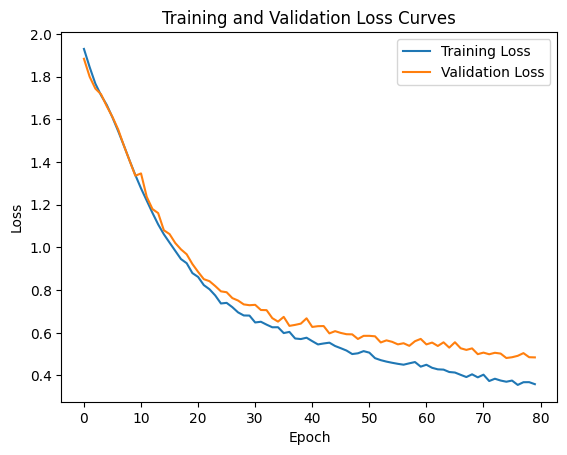

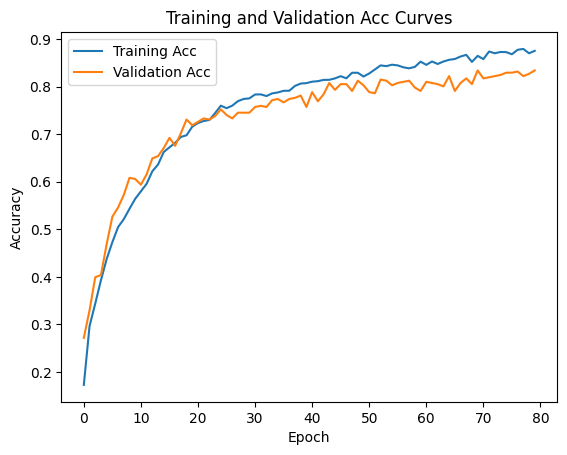

In [7]:
test(myModel_a, device, criterion, test_loader, 'Test')

def lossPlot(train_losses, val_losses):
    plt.plot(train_losses, label='Training Loss')
    plt.plot(val_losses, label='Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Training and Validation Loss Curves')
    plt.legend()
    plt.show()

def accuracyPlot(train_accuracy, val_accuracy):
    plt.plot(train_accuracy, label='Training Acc')
    plt.plot(val_accuracy, label='Validation Acc')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.title('Training and Validation Acc Curves')
    plt.legend()
    plt.show()
    
lossPlot(train_losses_a, val_losses_a)
accuracyPlot(train_accuracy_a, val_accuracy_a)


/user/HS401/ob00564/Documents/COM3001/All/Transfer Learning
/user/HS401/ob00564/Documents/COM3001


/tmp/ipykernel_194565/1632659219.py:6: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  mobilenet.load_state_dict(torch.load('All MobileNet.pth'))


Test Loss: 0.4817, Test Accuracy: 82.35%


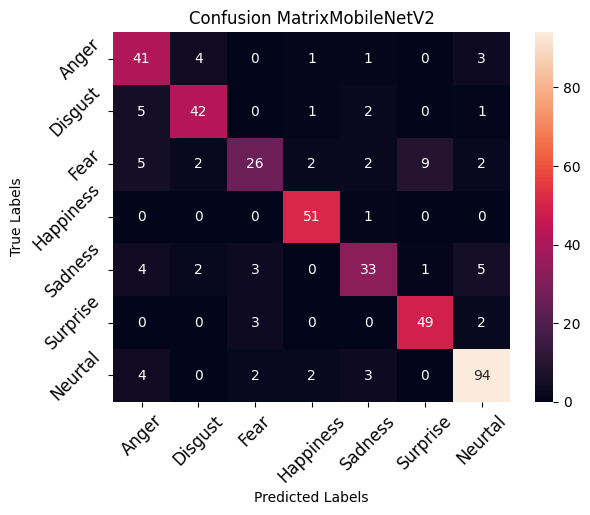

              precision    recall  f1-score   support

       Anger     0.6949    0.8200    0.7523        50
     Disgust     0.8400    0.8235    0.8317        51
        Fear     0.7647    0.5417    0.6341        48
   Happiness     0.8947    0.9808    0.9358        52
     Sadness     0.7857    0.6875    0.7333        48
    Surprise     0.8305    0.9074    0.8673        54
     Neurtal     0.8785    0.8952    0.8868       105

    accuracy                         0.8235       408
   macro avg     0.8127    0.8080    0.8059       408
weighted avg     0.8226    0.8235    0.8193       408



In [ ]:
y_true, y_pred, y_score = test(myModel_a, device, criterion, test_loader, 'Test')
confusionMatrixPlot(y_true, y_pred, ' MobileNetV2')